In [19]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [20]:
g = 9.81     # gravity (m/s^2)
L = 1.0      # length (m)
theta_0 = 0.2  # initial angle (rad)

t_min, t_max = 0.0, 10.0

In [21]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32,32),
            nn.Tanh(),
            nn.Linear(32,1)
        )
    def forward(self, t):
        return self.net(t)

In [22]:
def pinn_loss(model, t):
    t.requires_grad = True

    theta = model(t)

    theta_t = torch.autograd.grad(
        theta, t, grad_outputs = torch.ones_like(theta), create_graph = True
    )[0]

    theta_tt = torch.autograd.grad(
        theta_t, t, grad_outputs=torch.ones_like(theta_t), create_graph=True
    )[0]

    physics_residual = theta_tt + (g / L) * theta

    physics_loss = torch.mean(physics_residual**2)

    theta_0_pred = model(torch.tensor([[0.0]]))
    theta_t_0_pred = theta_t[0]

    ic_loss = (theta_0_pred - theta_0)**2 + theta_t_0_pred**2

    return physics_loss + ic_loss

In [23]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 100000

loss_history = []

for epoch in range(epochs+1):
    optimizer.zero_grad()

    t_train = torch.linspace(t_min, t_max, 100).reshape(-1, 1)
    loss = pinn_loss(model, t_train)

    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

Epoch 0, Loss = 8.907380
Epoch 500, Loss = 0.032149
Epoch 1000, Loss = 0.029747
Epoch 1500, Loss = 0.025373
Epoch 2000, Loss = 0.022164
Epoch 2500, Loss = 0.021049
Epoch 3000, Loss = 0.020065
Epoch 3500, Loss = 0.019183
Epoch 4000, Loss = 0.018494
Epoch 4500, Loss = 0.018038
Epoch 5000, Loss = 0.017735
Epoch 5500, Loss = 0.018365
Epoch 6000, Loss = 0.017198
Epoch 6500, Loss = 0.016928
Epoch 7000, Loss = 0.016430
Epoch 7500, Loss = 0.015888
Epoch 8000, Loss = 0.015313
Epoch 8500, Loss = 0.014705
Epoch 9000, Loss = 0.014128
Epoch 9500, Loss = 0.013486
Epoch 10000, Loss = 0.014766
Epoch 10500, Loss = 0.012507
Epoch 11000, Loss = 0.012248
Epoch 11500, Loss = 0.012153
Epoch 12000, Loss = 0.012083
Epoch 12500, Loss = 0.012038
Epoch 13000, Loss = 0.012025
Epoch 13500, Loss = 0.011991
Epoch 14000, Loss = 0.011969
Epoch 14500, Loss = 0.011962
Epoch 15000, Loss = 0.011938
Epoch 15500, Loss = 0.011945
Epoch 16000, Loss = 0.011912
Epoch 16500, Loss = 0.011907
Epoch 17000, Loss = 0.011887
Epoch 175

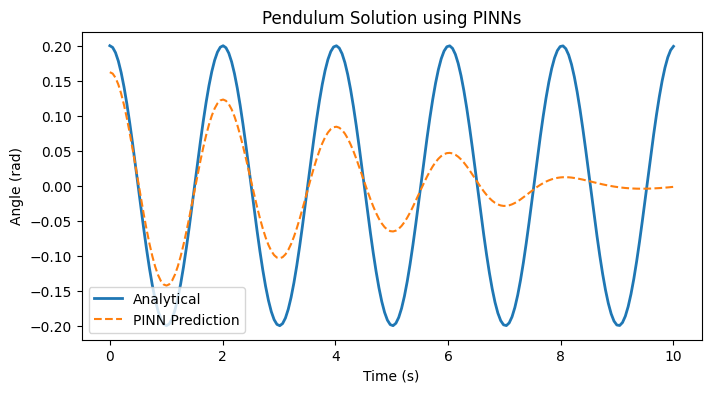

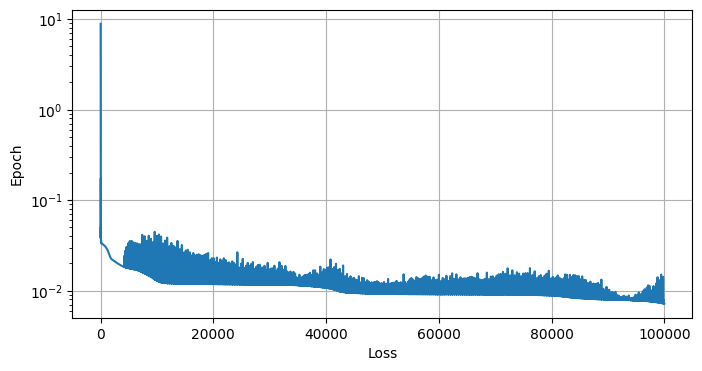

In [24]:
t_test = torch.linspace(t_min, t_max, 200).reshape(-1, 1)
theta_pinn = model(t_test).detach().numpy()

omega = np.sqrt(g / L)
theta_exact = theta_0 * np.cos(omega * t_test.numpy())

plt.figure(figsize=(8, 4))
plt.plot(t_test, theta_exact, label="Analytical", linewidth=2)
plt.plot(t_test, theta_pinn, "--", label="PINN Prediction")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.legend()
plt.title("Pendulum Solution using PINNs")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Loss")
plt.ylabel("Epoch")
plt.yscale("log")
plt.grid(True)
plt.show()